In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

#coffee_data = pd.read_csv(r"..\data\reduced_data_num.csv")
coffee_data = pd.read_csv(r"..\data\reduced_data_bin.csv")

column_names = coffee_data.drop(columns=['caffeine_class', 'caffeine_percent']).columns


filtered_data = coffee_data[coffee_data['caffeine_class'] == 1]

X = filtered_data.drop(columns=["caffeine_class", "caffeine_percent"])
y = filtered_data['caffeine_percent']

In [3]:

# 1) Define the “high‐caffeine” threshold
THRESH = 0.70

# 2) Classifier feature matrix is just X (all 94 caffeinated rows)
X_pos = X.copy()

# 3) Binary label: 1 if at or above the high mode, else 0
y_high = (y >= THRESH).astype(int)

# (Optional) reset indices if you plan to concatenate or merge later
X_pos = X_pos.reset_index(drop=True)
y_high = y_high.reset_index(drop=True)

print(X_pos.shape, y_high.value_counts())


(94, 88) caffeine_percent
0    87
1     7
Name: count, dtype: int64


In [4]:
from lightgbm import LGBMClassifier

clf = LGBMClassifier(
    objective='binary',
    n_estimators=1200,
    learning_rate=0.01,
    num_leaves=8,
    min_data_in_leaf=5,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=1,
    is_unbalance=True,
    random_state=42
)
clf.fit(X_pos, y_high)  # X_pos: 94×p, y_high: 0/1 labels


[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Info] Number of positive: 7, number of negative: 8

LGBMClassifier(bagging_fraction=0.8, bagging_freq=1, feature_fraction=0.8,
               is_unbalance=True, learning_rate=0.01, min_data_in_leaf=5,
               n_estimators=1200, num_leaves=8, objective='binary',
               random_state=42)

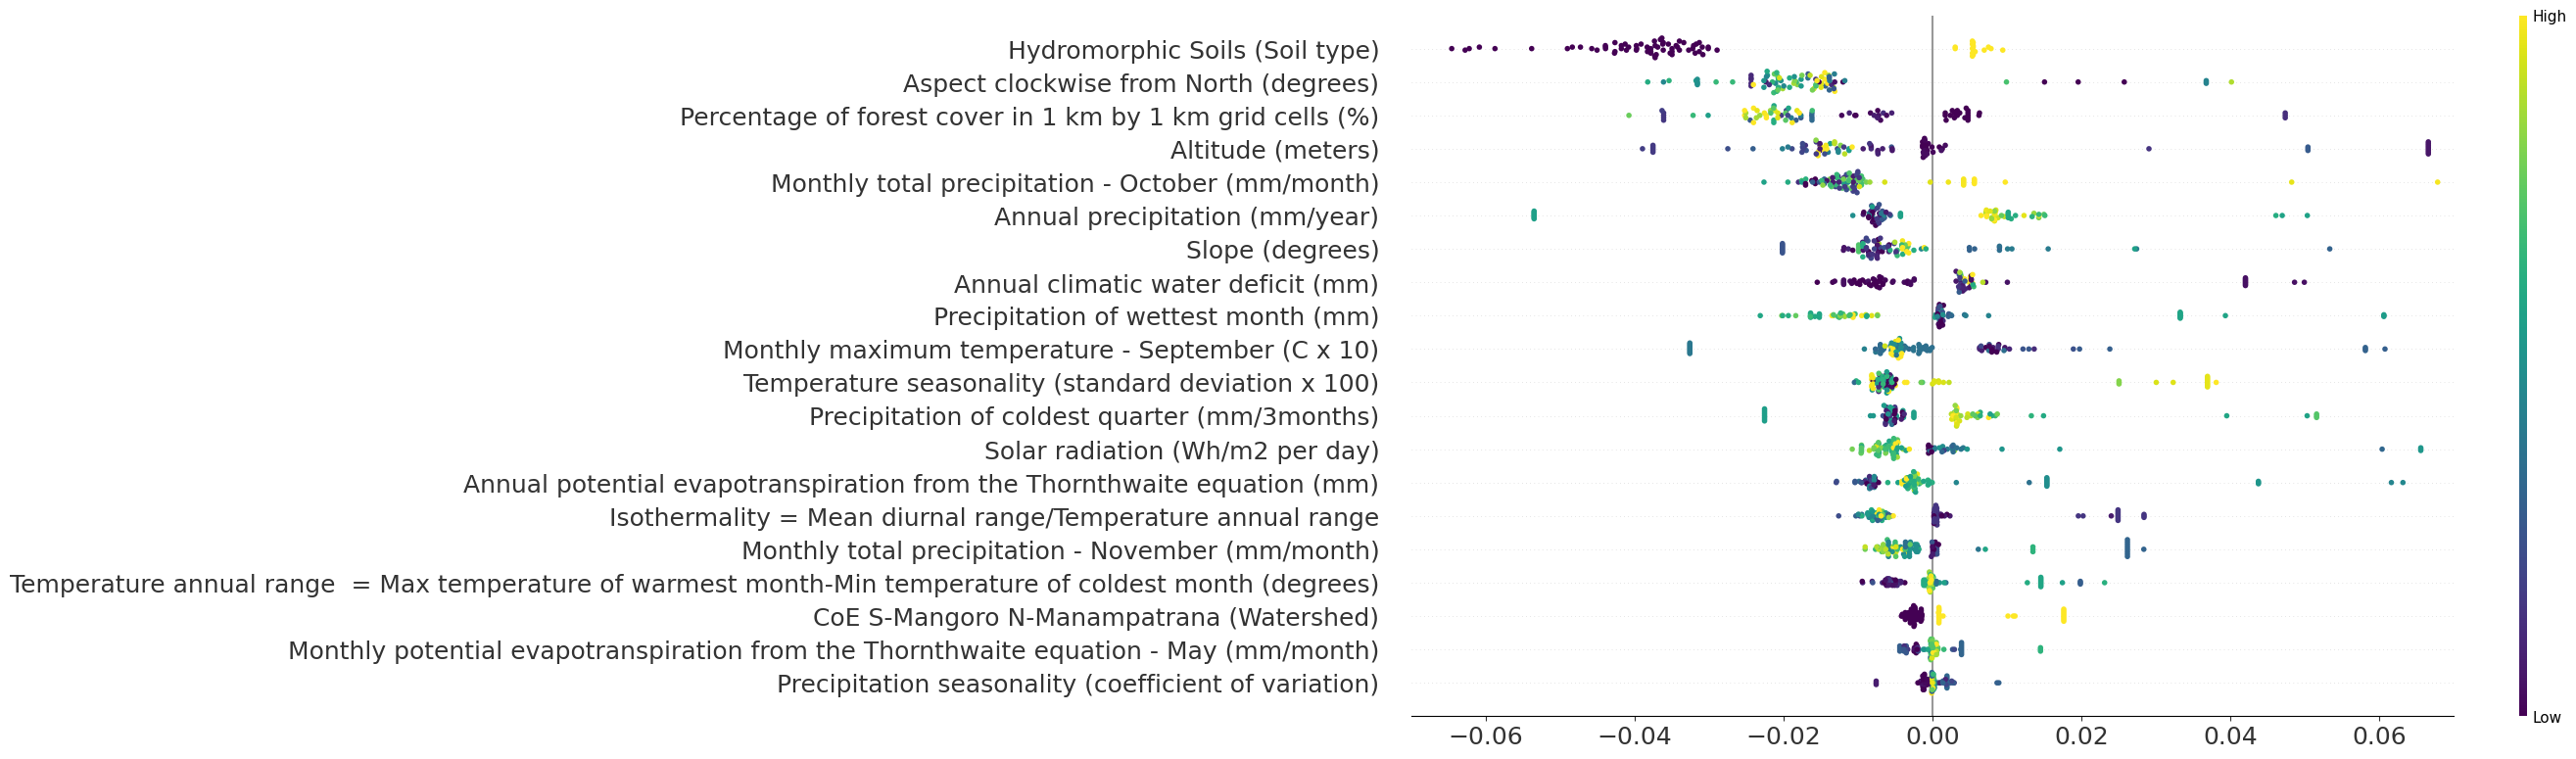

c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\plots\_beeswarm.py:950: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  pl.tight_layout()


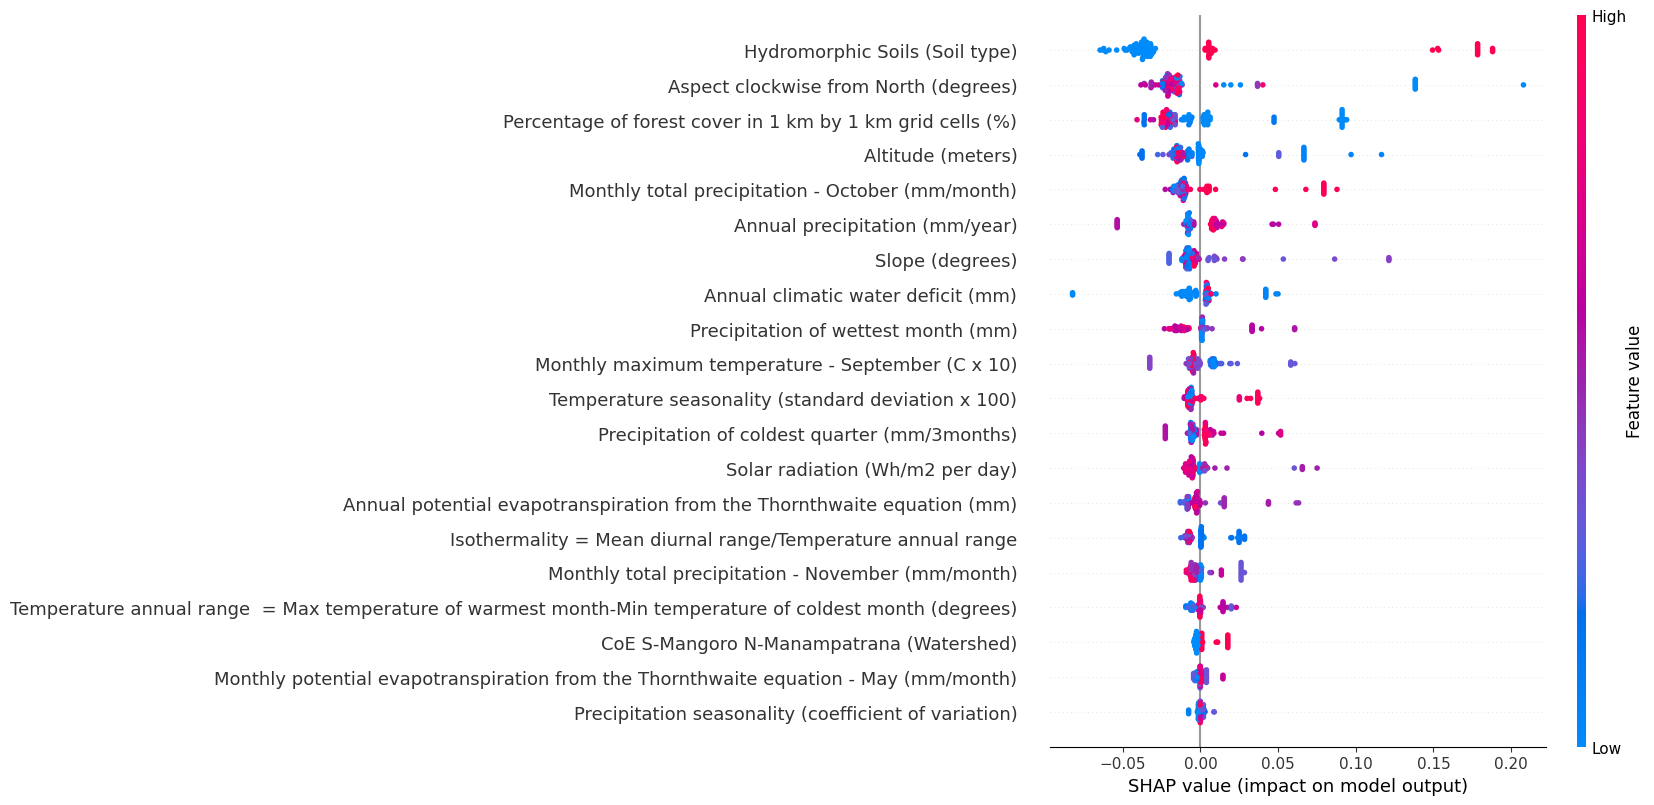

In [11]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

file_path = r'../input/column_mapping.csv'  

# Read the CSV file into a DataFrame
column_mapping = pd.read_csv(file_path)

name_mapping = dict(zip(column_mapping['new_name'], column_mapping['long_name']))


explainer = shap.TreeExplainer(
    clf,
    data    = X_pos, 
    model_output='probability',
    feature_perturbation='interventional'
)

shap_values = explainer.shap_values(X_pos)  # class=1 (high)

if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]          # list-of-arrays format
else:
    shap_values_class1 = shap_values 


# Replace feature names in the SHAP summary plot data
X_train_renamed = X_pos.rename(columns=name_mapping)



plt.figure(figsize=(14, 8))  # Adjust figure size for a wider plot
shap.summary_plot(shap_values_class1, X_train_renamed, plot_size=(24, 8), show=False, cmap='viridis')
plt.xlim(-0.07, 0.07)  # Expand x-axis limits to better view values around 0

fig = plt.gcf()
for ax in fig.axes:
    if 'colorbar' in ax.get_label().lower():
        colorbar = ax  # Identify the color bar axis
        colorbar.set_ylabel('')  # Remove the label from the color bar

#plt.title('SHAP Summary Plot')
plt.xlabel('')
plt.ylabel('')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.show()


shap.summary_plot(shap_values_class1, X_train_renamed)



Top predictors
Hydromorphic Soils (Soil type)
Almost every dot lies far to the left, indicating that presence of hydromorphic (water‑logged) soils strongly decreases the probability of high caffeine.

Aspect clockwise from North (degrees)
Here yellow dots (high aspect values: southern exposures) sit to the right—southern, sun‑facing slopes increase high‑caffeine probability—whereas purple (northern aspects) push toward low caffeine.

Percentage of forest cover
Low forest cover (purple) yields positive SHAP—more open canopy increases high‑caffeine likelihood—while dense cover (yellow) suppresses it.

Altitude (meters)
Mid‑range altitudes (green) skew slightly positive; the very highest and lowest elevations tend toward negative SHAP (too high or too low elevation doesn’t favor the high‑caffeine mode).

Mid‑ranked predictors
Monthly total precipitation—October and Annual precipitation
Wetter conditions in October and overall rainfall show a mixed pattern: moderate precipitation (mid‑color) tends to push toward high caffeine, but extremes (both low and high) attenuate that effect.

Slope (degrees) and Annual climatic water deficit
Moderate slopes and intermediate water deficit values nudge the model toward high caffeine, consistent with a stress‑response hypothesis.

Lower‑ranked predictors
Features like temperature seasonality, solar radiation, and various monthly PET/precipitation metrics appear near zero—meaning they have almost no influence on the classifier’s decision.

Biological takeaway
High caffeine concentrations are most likely where soils are non‑hydromorphic, the slope is south‑facing, forest cover is open, and elevation is moderate—all conditions that plausibly elevate plant stress (light, temperature, water) and trigger caffeine synthesis. Conversely, water‑logged soils, northern aspects, dense canopy, and extreme elevations suppress the high‑caffeine phenotype.